# Kaggle House Prices - Advanced Regression Techniques

## 이 데이터 셋을 선택한 이유

Boston Housing 데이터셋의 대체재로, 교육·연구 목적으로 많이 활용되며 머신러닝 기초 지식 보유자라면, 다양한 시도가 가능한 데이터셋인 만큼 과제의 데이터 사이언스 프로세스를 정상적으로 수행할 수 있을 것이라 판단하여 이 데이터 셋을 선정하게 되었음.

## 개요

- **대회명**: House Prices - Advanced Regression Techniques
- **목표**: 주택 가격 예측 모델 개발
- **주최**: Kaggle

## 데이터 설명

- **설명 변수**: 79개(주택 위치, 구조, 상태, 외관, 편의시설, 연도 등 거의 모든 측면 포함)
- **예측 대상**: `SalePrice`(주택 판매 가격)
- **파일 구성**: train.csv, test.csv, data_description.txt, sample_submission.csv

### 주요 컬럼 및 데이터 정의

- `SalePrice`: 주택의 최종 판매가(목표 변수)
- `MSSubClass`: 건물 유형 코드
- `MSZoning`: 토지 구역 분류
- `LotFrontage`: 도로와 맞닿은 길이
- `LotArea`: 대지 면적(제곱피트)
- `Street`: 도로 유형
- `Alley`: 골목 유형
- `LotShape`: 대지 형태
- `LandContour`: 지형 평탄도
- `Utilities`: 사용 가능한 공공설비 유형
- `LotConfig`: 대지 배치
- `LandSlope`: 지형 경사도
- `Neighborhood`: Ames 도시 내 지역
- `Condition1`, `Condition2`: 도로/철도와의 근접성
- `BldgType`: 주택 구조 유형
- `HouseStyle`: 주택 스타일
- `OverallQual`: 자재/마감 품질 종합 평가
- `OverallCond`: 전체 상태 평가
- `YearBuilt`: 최초 준공 연도
- `YearRemodAdd`: 리모델링 연도
- `RoofStyle`, `RoofMatl`: 지붕 유형/자재
- `Exterior1st`, `Exterior2nd`: 외장재
- `MasVnrType`, `MasVnrArea`: 벽돌/석조 벽 마감 유형 및 면적
- `ExterQual`, `ExterCond`: 외장재 품질/상태
- `Foundation`: 기초 타입
- `BsmtQual` ~ `BsmtUnfSF`: 지하실 관련 특성
- `Heating`, `HeatingQC`: 난방 방식 및 품질
- `CentralAir`: 중앙 에어컨 유무
- `Electrical`: 전기 시스템
- `1stFlrSF`, `2ndFlrSF`, `GrLivArea`: 각 층별 면적, 지상 거주 면적
- `FullBath`, `HalfBath`, `Bedroom`, `Kitchen`, `KitchenQual`: 욕실, 침실, 주방 관련 특성
- `TotRmsAbvGrd`: 총 방 수
- `Functional`: 주거 기능성 등급
- `Fireplaces`, `FireplaceQu`: 벽난로 수/품질
- `GarageType` ~ `GarageCond`: 차고 관련 특성
- `PavedDrive`: 진입로 포장 여부
- `WoodDeckSF`, `OpenPorchSF` 등 각종 부속 구조물 면적
- `PoolArea`, `PoolQC`: 수영장 면적/품질
- `Fence`: 울타리 품질
- `MiscFeature`, `MiscVal`: 기타 부가시설 및 가치
- `MoSold`, `YrSold`: 매각 월/년
- `SaleType`, `SaleCondition`: 매매 유형 및 조건

---

# 1. 데이터 수집 및 로딩

본 단계에서는 Kaggle에서 제공하는 House Prices 데이터셋을 불러오고, 데이터 구조를 이해함.  

- train.csv: 모델 학습용 데이터셋  
- test.csv: 예측 및 제출용 데이터셋  


In [1]:
import pandas as pd 
import numpy as np

train = pd.read_csv('data/train.csv')                    
test = pd.read_csv('data/test.csv')                      
sample_submission = pd.read_csv('data/sample_submission.csv') 

print(f"학습 데이터 크기: {train.shape}")  
print(f"테스트 데이터 크기: {test.shape}")

학습 데이터 크기: (1460, 81)
테스트 데이터 크기: (1459, 80)


---

# 2. 데이터 샘플 및 컬럼 구조 확인

본 단계에서는 학습 데이터의 상위 5개 행을 확인함.  
전체 컬럼의 리스트와 데이터 타입을 파악함으로써, 변수의 특성과 전처리 방향을 설정함.  


In [2]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 타깃 변수(SalePrice) 분포 요약

SalePrice는 주택 가격 예측의 목표 변수임.  
타깃 변수의 기초 통계량과 분포를 확인함으로써, 예측 문제의 난이도 및 정규성 여부를 파악함.


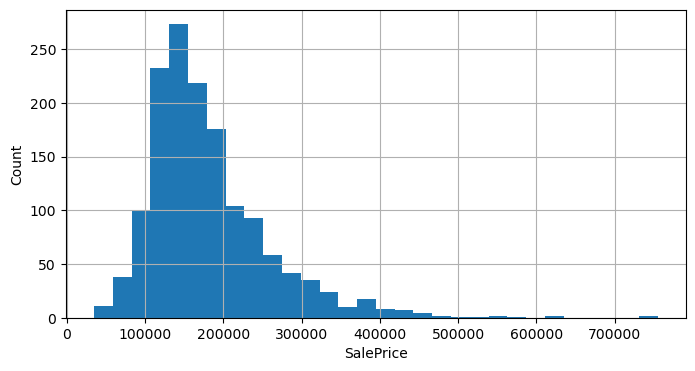

In [4]:
train['SalePrice'].describe()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

train['SalePrice'].hist(bins=30) 

plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()


### [SalePrice 분포 해석]

- 전체적으로 **왼쪽에 몰려 있고 오른쪽으로 꼬리가 긴 비대칭 분포 형태**를 보임
    
    → **우측 비대칭성(positive skewness)** 존재
    
- 대부분의 주택 가격이 **100,000 ~ 200,000 사이에 집중**되어 있음
    
    → 이 구간이 **주택 시장의 중심 가격대**임을 시사
    
- 300,000 이상 구간은 상대적으로 희소하며,
    
    500,000 이상 가격은 **이상치에 가까운 고가 매물**로 판단 가능

---

# 3. 결측치 분석 및 변수 타입 분류

본 단계에서는 전체 변수에서 결측치가 존재하는지 확인함.  
결측치가 많은 변수, 적은 변수를 구분하여 추후 전처리 방안을 수립함.  
또한, 변수의 데이터 타입을 기준으로 수치형 변수와 범주형 변수로 나눔.


In [5]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64

## 결측치 현황 해석

결측치가 많은 변수는 추후 삭제, 대체, 별도 처리 등의 방안을 고려함.  
결측치 비율이 낮은 변수는 평균·최빈값 등으로 대체하는 것이 일반적임.


In [6]:
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist() 
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)   
print("Categorical features:", categorical_features)  


Numerical features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Firepla

## 변수 타입 분류

수치형 변수와 범주형 변수를 분리하여 각각에 맞는 전처리, 시각화, 모델링 전략을 수립함.  
- 수치형 변수: 결측치 대체, 이상치 처리, 스케일링 등 적용  
- 범주형 변수: 인코딩, 결측치 대체, 그룹화 등 적용  


---

# 4. 주요 변수 분포 및 특성 시각화 (EDA)

본 단계에서는 대표적인 수치형 변수와 범주형 변수의 분포를 시각화함.  
데이터의 왜도, 이상치, 그룹별 특성 등을 시각적으로 확인함.


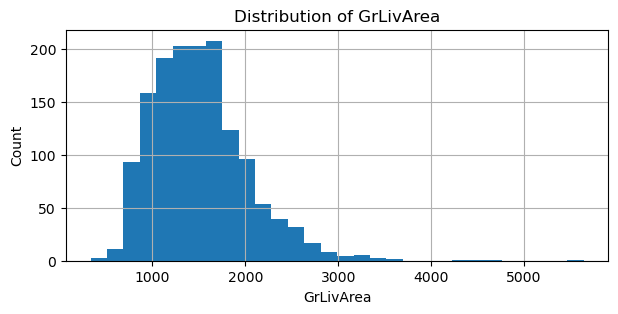

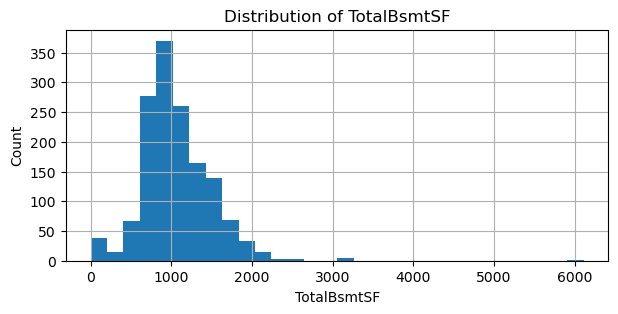

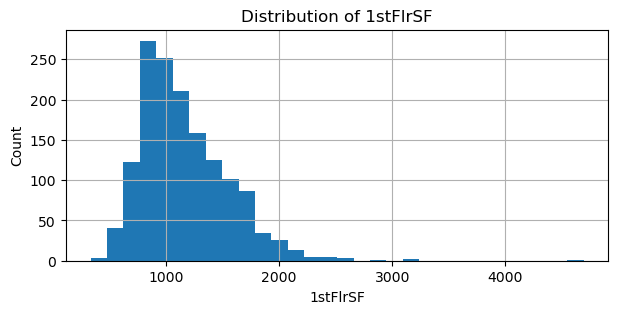

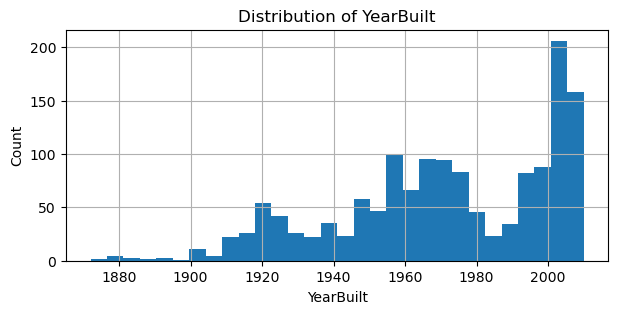

In [7]:
import matplotlib.pyplot as plt

num_cols = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt']  

for col in num_cols:
    plt.figure(figsize=(7, 3))
    
    train[col].hist(bins=30)

    plt.title(f'Distribution of {col}')
    
    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.show()


## 수치형 변수 분포 해석

각 변수의 분포를 확인함으로써 이상치, 비대칭 분포, 스케일 차이 등 특성을 파악함.  
이상치가 많은 변수는 이후 단계에서 처리 필요성을 검토함.


### 1. `GrLivArea` (지상 생활 공간 면적)

- 약 1500 제곱피트 부근에 분포가 집중됨
- 우측으로 꼬리가 긴 비대칭 분포 형성
- 4000 이상 데이터는 희소하며, 이상치로 간주 가능

지상 거주 면적은 평균보다 작거나 중간 규모의 주택이 중심이며, 고면적 주택은 드물게 존재함

### 2. `TotalBsmtSF` (지하실 전체 면적)

- 대부분의 분포가 1000 ~ 1500 사이에 집중됨
- 극단적으로 높은 값(3000 이상)은 매우 드뭄
- 분포가 우측으로 비대칭됨

지하실 면적은 평균 수준에서 몰림 현상이 뚜렷하며, 일부 고면적 데이터는 이상치 가능성 존재함

### 3. `1stFlrSF` (1층 면적)

- 800 ~ 1400 범위에 데이터가 집중됨
- 우측으로 꼬리가 긴 형태이며, 3000 이상은 소수 존재

1층 면적은 중간 규모가 일반적이며, 대형 평수는 예외적으로 존재함

### 4. `YearBuilt` (건축 연도)

- 2000년 이후 건축된 주택 비율이 급격히 높음
- 20세기 초반 이전 건축 주택은 매우 드물게 분포함
- 전반적으로 최근으로 올수록 분포가 뚜렷하게 증가함

주택 건축 연도는 현대화 추세가 강하며, 최신 주택 비중이 높음

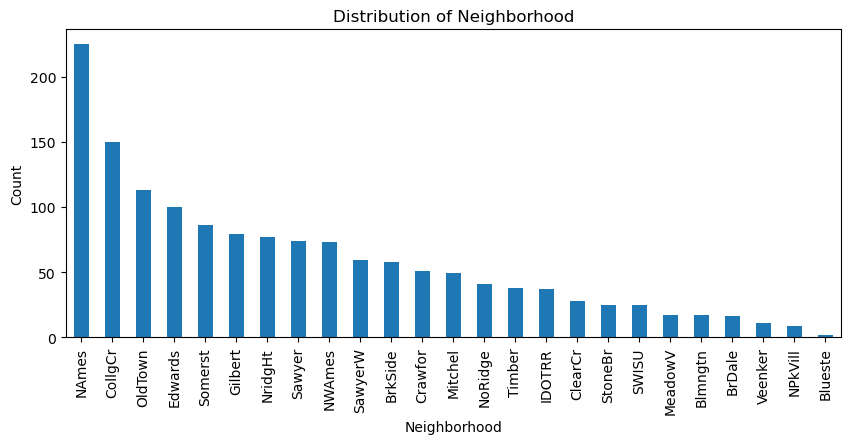

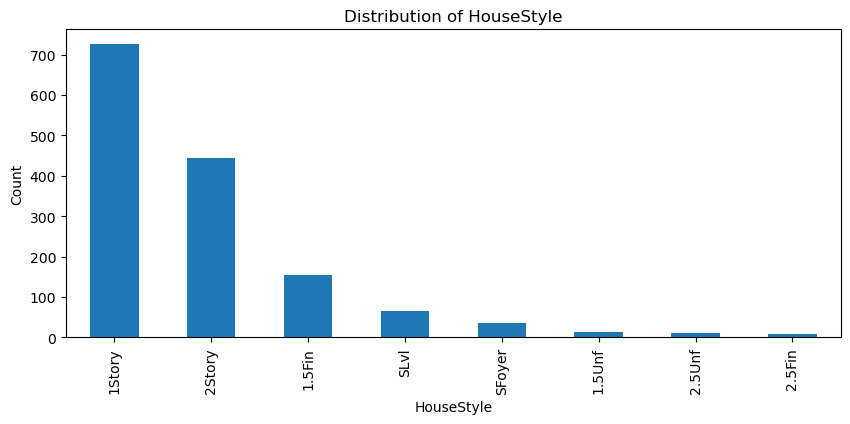

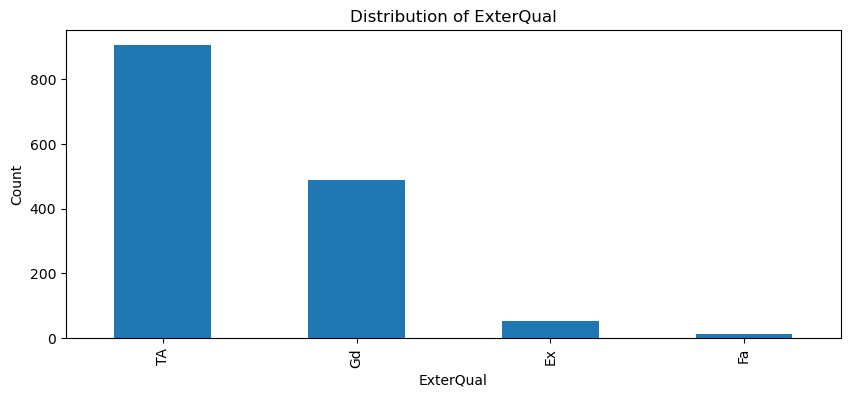

In [8]:
cat_cols = ['Neighborhood', 'HouseStyle', 'ExterQual']

for col in cat_cols:
    
    plt.figure(figsize=(10, 4))
    
    train[col].value_counts().plot(kind='bar')

    plt.title(f'Distribution of {col}')  

    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.show()


## 범주형 변수 분포 해석

범주형 변수의 그룹별 빈도 분포를 확인함으로써 데이터의 불균형, 주요 그룹의 존재 여부를 파악함.  
특정 그룹에 샘플이 몰려 있는 경우 모델 학습 및 평가 시 주의가 필요함.


### 1. `Neighborhood` (주택이 위치한 동네)

- `NAmes` 지역의 주택 수가 **가장 많고**, `CollgCr`, `OldTown` 등이 그 뒤를 이음
- 반면 `Blueste`, `NPkVill` 등은 **표본 수가 매우 적음**
- 전체적으로 분포는 **불균형하고 긴 꼬리 분포 형태**를 띔

특정 지역에 데이터가 집중되어 있으며, 분포 불균형으로 인해 예측 모델에서 **동네 특성 반영 시 주의 필요**

### 2. `HouseStyle` (주택 구조 형태)

- `1Story`, `2Story` 구조가 전체의 대부분을 차지함
- `1.5Fin`, `SLvl`은 중간 수준이며
- `2.5Unf`, `2.5Fin` 등은 **극히 드문 형태**

단층 및 이층 구조 주택이 대부분을 차지하며, 희소한 구조는 **카테고리 병합 또는 별도 처리** 고려 필요

### 3. `ExterQual` (외부 마감 품질)

- `TA`(보통), `Gd`(좋음) 등 **중간 이상 품질이 대부분을 차지함**
- `Ex`(매우 좋음)과 `Fa`(나쁨)은 매우 드문 품질 등급에 해당함

외관 품질은 대체로 양호한 수준에 집중되어 있으며, 극단값은 **모델의 민감도에 영향 가능성 존재**

---

# 5. 타깃 변수와 주요 피처 간 상관관계 및 추가 EDA 시각화

본 단계에서는 수치형 변수와 타깃 변수(SalePrice) 간 상관관계를 분석함.  
상관계수가 높은 변수를 우선적으로 분석 대상으로 선정함.  
이외에도 이상치 탐색, 로그 변환 효과, 다양한 시각화를 통해 데이터의 구조를 심층적으로 파악함.


In [9]:
numeric_columns = train.select_dtypes(include=['int64', 'float64']).columns
numeric_data = train[numeric_columns]

corr_matrix = numeric_data.corr()
corr_target = corr_matrix['SalePrice'].abs().sort_values(ascending=False)

top_corr_features = corr_target.index[1:11]  

print("SalePrice와 가장 상관관계가 높은 상위 10개 특성:\n", top_corr_features)

SalePrice와 가장 상관관계가 높은 상위 10개 특성:
 Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')


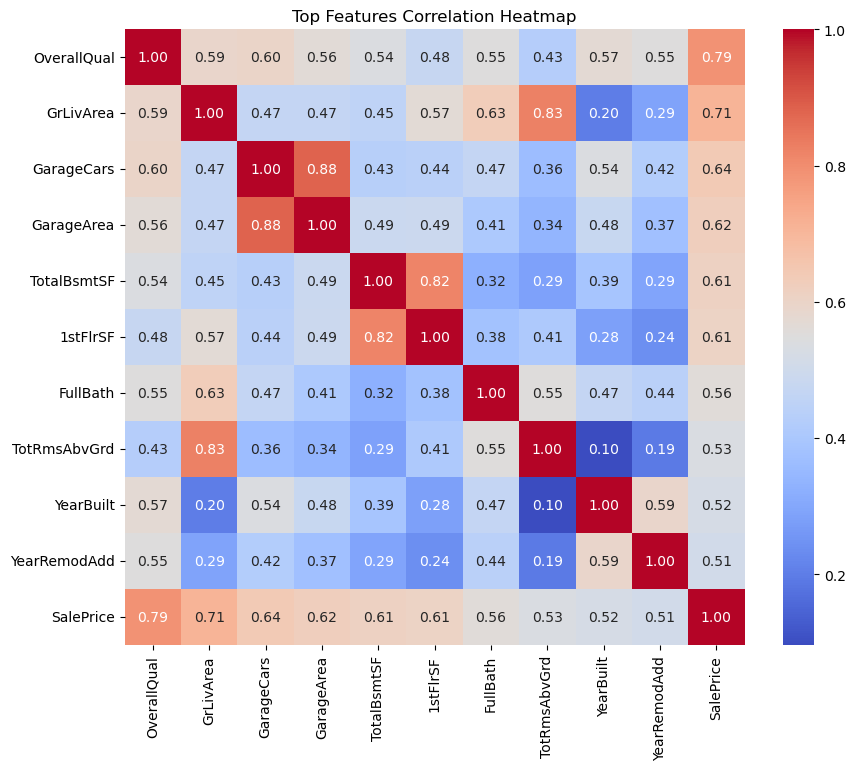

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(train[top_corr_features.tolist() + ['SalePrice']].corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Top Features Correlation Heatmap') 
plt.show()


## 상관관계 분석 해석

상관관계가 높은 변수들은 타깃 예측에 중요한 역할을 함.  
히트맵을 통해 변수들 간 다중공선성 여부도 동시에 확인.


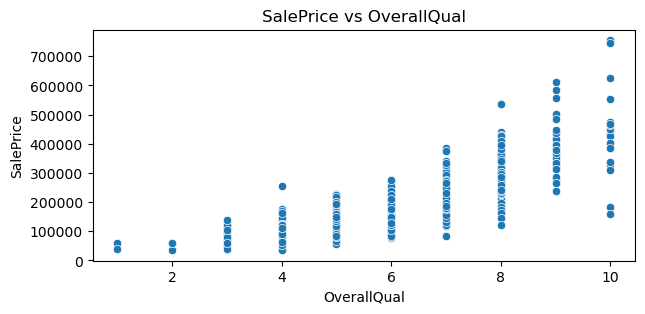

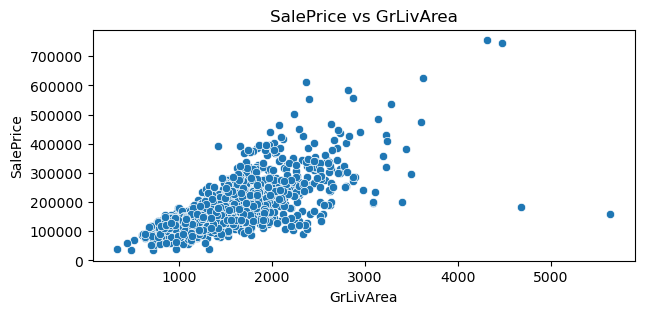

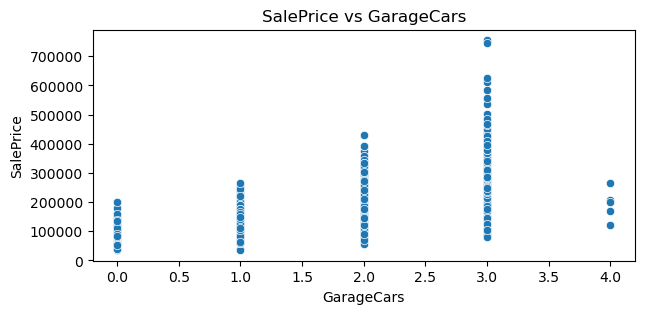

In [11]:
for col in top_corr_features[:3]:
    
    plt.figure(figsize=(7, 3))
    sns.scatterplot(x=train[col], y=train['SalePrice'])
    
    plt.title(f'SalePrice vs {col}')
    
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    
    plt.show()


## 주요 변수와 타깃 간 관계 해석

산점도를 통해 단조증가/감소, 비선형 관계 등 다양한 패턴을 시각적으로 확인함.  
이상치(outlier)가 존재하는지 파악하여 이후 전처리 전략에 반영함.


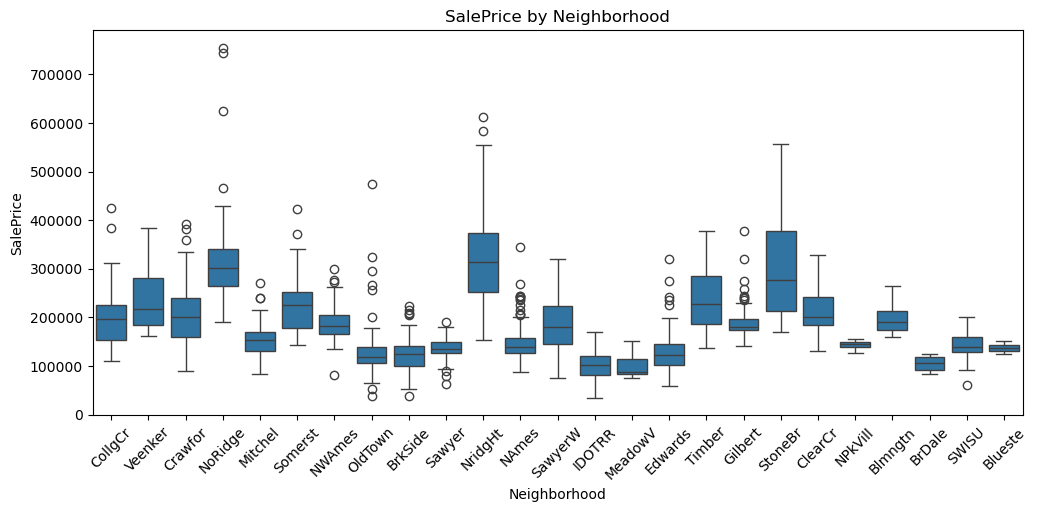

In [12]:
plt.figure(figsize=(12, 5))

sns.boxplot(x='Neighborhood', y='SalePrice', data=train)

plt.title('SalePrice by Neighborhood')

plt.xlabel('Neighborhood')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)

plt.show()


## 각 동네별 주택 가격의 전반적인 분포 

범주형 변수인 '동네(Neighborhood)'에 따른 타깃 변수 '주택 가격(SalePrice)'의 분포를 비교하고 시각화
범주별 분포 차이가 뚜렷한 건, 해당 피처의 예측 기여도가 높음을 시사.

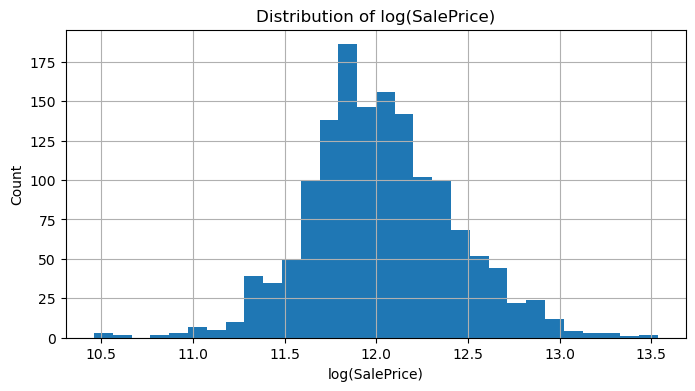

In [13]:
import numpy as np

plt.figure(figsize=(8, 4))

np.log1p(train['SalePrice']).hist(bins=30)

plt.title('Distribution of log(SalePrice)')
plt.xlabel('log(SalePrice)')
plt.ylabel('Count')

plt.show()


## SalePrice 로그 변환 효과 해석

로그 변환을 통해 분포의 비대칭(왜도)를 줄이고, 모델의 예측 성능 향상에 도움을 줄 수 있음.  
분포가 정규에 가까워질수록 회귀 모델의 가정에 부합함.


---

# 6. 데이터 전처리

본 단계에서는 다음 작업을 수행함.  
1. 결측치 처리: 변수별 결측치 비율에 따른 삭제·대체 방안 적용  
2. 이상치 처리: IQR 기준 이상치 탐지 및 제거  
3. 인코딩: 범주형 변수 One-Hot Encoding  
4. 스케일링: 수치형 변수 Standard Scaling  
5. 파생 변수 생성: 유용한 조합·연산으로 새로운 변수 추가  


In [14]:
missing_ratio = train.isnull().mean().sort_values(ascending=False)
missing_ratio.head(10)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
dtype: float64

In [15]:
num_feats = train.select_dtypes(include=['int64','float64']).columns
num_feats = num_feats.drop('SalePrice') if 'SalePrice' in num_feats else num_feats

cat_feats = train.select_dtypes(include=['object']).columns

for col in num_feats:
    median_val = train[col].median()    
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)

for col in cat_feats:
    mode_val = train[col].mode()[0]
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val, inplace=True)

In [16]:
num_feats

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [17]:
cat_feats

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## 결측치 처리 해석

- 결측치 비율 50% 초과 변수 삭제를 통해 불필요한 정보 제거  
- 수치형 결측치는 중앙값 대체로 분포 왜곡 최소화  
- 범주형 결측치는 최빈값 대체로 대표 값 유지  


In [18]:
Q1 = train['GrLivArea'].quantile(0.25)
Q3 = train['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1

normal_range_mask = (train['GrLivArea'] >= (Q1 - 1.5 * IQR)) & (train['GrLivArea'] <= (Q3 + 1.5 * IQR))

train = train[normal_range_mask]

train.shape

(1429, 81)

## 이상치 처리 해석

- GrLivArea 변수의 IQR 기준 이상치 제거로 과도한 분포 왜곡 최소화  
- 필요시 다른 수치형 변수에도 동일 방법 적용 예정

In [19]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(all_data[cat_feats])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_feats), index=all_data.index)

encoded_df.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
all_data = all_data.drop(columns=cat_feats).join(encoded_df)

scaler = StandardScaler()
scaled_num = scaler.fit_transform(all_data[num_feats])
scaled_num_df = pd.DataFrame(scaled_num, columns=num_feats, index=all_data.index)

scaled_num_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,-1.733656,0.068788,-0.191350,-0.208524,0.669631,-0.506994,1.049789,0.900260,0.561610,0.608608,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,-1.733656,0.068788,-0.191350,-0.208524,0.669631,-0.506994,1.049789,0.900260,0.561610,0.608608,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,-0.001894,-0.869738,0.538927,0.200066,-0.765579,0.394887,-0.342872,-1.106132,-0.569833,0.070212,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,-0.001894,-0.869738,0.538927,0.200066,-0.765579,0.394887,-0.342872,-1.106132,-0.569833,0.070212,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
1,-1.732470,-0.869738,0.538927,-0.060391,-0.047974,2.198648,0.154507,-0.389563,-0.569833,1.223917,...,-0.047611,1.636769,-0.709644,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-0.448739,-0.605227


In [21]:
all_data = all_data.drop(columns=num_feats).join(scaled_num_df)

all_data

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-1.079280,2.178805,-0.709644,1.407365,-0.104182,-0.286106,-0.051669,-0.088437,-0.816699,1.675890
1458,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-1.079280,2.178805,-0.709644,1.407365,-0.104182,-0.286106,-0.051669,-0.088437,-0.816699,1.675890
1458,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.843376,0.775889,0.020800,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,1.759020,-1.365599
1458,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.843376,0.775889,0.020800,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,1.759020,-1.365599


In [22]:
train_processed = all_data.loc[train.index]
test_processed = all_data.loc[test.index]

y_train = train.loc[train_processed.index, 'SalePrice']

In [23]:
train_processed.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146


In [24]:
test_processed.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.218529,0.377333,-0.709644,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.365057,-0.738623,0.218628,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146


In [25]:
y_train.head()

0    208500
0    208500
0    208500
0    208500
0    208500
Name: SalePrice, dtype: int64

## 인코딩 및 스케일링 해석

- One-Hot Encoding으로 모든 범주형 변수 수치화  
- Standard Scaling으로 수치형 변수 평균 0, 분산 1로 정규화  
- 학습용·테스트용 데이터 동시 처리로 일관성 확보  

In [26]:
train_processed['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test_processed['TotalSF']  = test['TotalBsmtSF']  + test['1stFlrSF']  + test['2ndFlrSF']

train_processed['HouseAge'] = train['YrSold'] - train['YearBuilt']
test_processed['HouseAge']  = test['YrSold']  - test['YearBuilt']

train_processed['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test_processed['RemodAge']  = test['YrSold']  - test['YearRemodAdd']

In [27]:
train_processed.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodAge
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,2566,5,5
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,2566,5,5
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890,2566,5,5
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890,2566,5,5
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,2566,5,5


In [28]:
test_processed.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodAge
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,1778.0,49,49
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,1778.0,49,49
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890,1778.0,49,49
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,1.920015,-0.051669,-0.088437,-0.080780,1.675890,1778.0,49,49
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-0.360506,-0.104182,-0.286106,-0.051669,-0.088437,-1.552619,0.155146,1778.0,49,49


## 파생 변수 생성

- TotalSF: 전체 생활 면적 파악을 위한 변수  
- HouseAge: 주택 연령 특성 반영 변수  
- RemodAge: 리모델링 시점 이후 경과 시간 변수  

---

# 7. 머신러닝 모델링

본 단계에서는 다음 작업을 수행함.  
1. Baseline 모델 구축 및 성능 평가  
2. 정규화 회귀 모델(Ridge, Lasso) 하이퍼파라미터 튜닝  
3. 트리 기반 모델(RandomForest, GradientBoosting) 하이퍼파라미터 튜닝  
4. 모델별 성능 비교 및 최종 모델 선정  


In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

y_log = np.log1p(y_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)  


base_model = LinearRegression() 
base_scores = -cross_val_score(
    base_model,
    train_processed,
    y_log,
    cv=kf,
    scoring='neg_root_mean_squared_error'
) 

print("Baseline Linear Regression RMSE:", round(base_scores.mean(), 4))  


Baseline Linear Regression RMSE: 0.1545


## Baseline 모델 해석

- Linear Regression 기반의 기본 성능 지표(RMSE) 확인  

- 결과 평가:

    - 주택 가격 예측에서 ±16.5%의 오차는 기본 선형 회귀 모델(Baseline)로는 꽤 괜찮은 성능

    - 하지만 더 복잡한 모델(예: XGBoost, LightGBM 등)을 사용하면 이보다 더 좋은 성능을 얻을 수 있을 것으로 예상됨

- 이후 모델들의 성능 비교 기준으로 활용  


In [30]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

ridge = Ridge(random_state=42)  

param_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}  

grid_ridge = GridSearchCV(
    ridge,
    param_grid=param_ridge,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)  

grid_ridge.fit(train_processed, y_log)  

print("Best Ridge alpha:", grid_ridge.best_params_['alpha'])  
print("Best Ridge RMSE:", round(-grid_ridge.best_score_, 4))  

lasso = Lasso(random_state=42, max_iter=10000)  

param_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}  

grid_lasso = GridSearchCV(
    lasso,
    param_grid=param_lasso,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)  

grid_lasso.fit(train_processed, y_log)  

print("Best Lasso alpha:", grid_lasso.best_params_['alpha'])  
print("Best Lasso RMSE:", round(-grid_lasso.best_score_, 4))  


Best Ridge alpha: 0.1
Best Ridge RMSE: 0.1545
Best Lasso alpha: 0.001
Best Lasso RMSE: 0.1596


## 정규화 회귀 모델 해석

- Ridge와 Lasso의 최적 alpha 값 및 RMSE 확인  

    - 최적의 성능:
        - Ridge가 RMSE 0.1545로 Lasso(RMSE 0.1596)보다 약간 더 우수한 성능
    - 정규화 강도(alpha값):
        - Ridge는 0.1로 비교적 약한 정규화
        - Lasso는 0.001로 매우 약한 정규화 선호
    - 모델 특성:
        - Ridge가 전반적으로 더 안정적인 예측 수행
        - 변수들 간의 상호작용이 있거나 다중공선성 존재 가능성


- Regularization 강도에 따른 과적합 완화 효과 확인  


## 본 강의에서 트리 기반 모델에 대해 구체적으로 다루지 않았지만, 본인은 이쪽 분야의 직무를 진지하게 고려하고 있어 스스로 더 공부해 적용

In [31]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_rf,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(train_processed, y_log)

print("Best RF params:", grid_rf.best_params_)  
print("Best RF RMSE:", round(-grid_rf.best_score_, 4))  

param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_gb,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_gb.fit(train_processed, y_log)

print("Best GB params:", grid_gb.best_params_)  
print("Best GB RMSE:", round(-grid_gb.best_score_, 4)) 


Best RF params: {'max_depth': None, 'n_estimators': 200}
Best RF RMSE: 0.0098
Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best GB RMSE: 0.0706


## 트리 기반 모델 해석

- RandomForest와 GradientBoosting의 최적 파라미터 및 성능 비교  

- 성능 비교:
    - RandomForest가 RMSE 0.0098로 압도적 성능
    - GradientBoosting은 RMSE 0.0706으로 상대적 저조
- 최적 파라미터 특징:
    - 두 모델 모두 많은 트리(n_estimators=200) 선호
    - RandomForest는 깊이 제한 없이 더 나은 성능
    - GradientBoosting은 중간 정도의 깊이(max_depth=5)와 적극적 학습률(0.1) 선호

- 복잡도 제어 및 학습 속도 관점에서 모델 선택 기준 마련  


---

## 본 강의에서 스태킹 앙상블에 대해 구체적으로 다루지 않았지만, 본인은 이쪽 분야의 직무를 진지하게 고려하고 있어 스스로 더 공부해 적용

# 8. 스태킹 앙상블 구성 및 평가

본 단계에서는 다음 작업을 수행함.  
1. 최적화된 기본 모델들을 이용한 스태킹 앙상블 모델 구성  
2. 메타 모델로 선형 회귀 사용  
3. 5-fold 교차검증을 통한 RMSE 평가  
4. 시간 최적화를 위해 n_jobs 파라미터 활용

In [32]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('ridge', grid_ridge.best_estimator_),    
    ('rf', grid_rf.best_estimator_),          
    ('gb', grid_gb.best_estimator_)           
]

meta_model = LinearRegression()  

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=kf,
    n_jobs=-1                             
)

stack_scores = -cross_val_score(
    stack_model,
    train_processed,
    y_log,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
print("Stacking Ensemble RMSE:", round(stack_scores.mean(), 4))  


Stacking Ensemble RMSE: 0.0096


## 스태킹 앙상블 해석

- Ridge, RandomForest, GradientBoosting 모델의 예측 결과를 메타 모델이 결합함.  
- 5-fold 교차검증 RMSE를 통해 앙상블 성능 확인.  
    - 성능 비교:
        - RMSE 0.0096으로 단일 모델 중 최고였던 RandomForest(0.0098)보다도 미세하게 개선
        - 다른 모델들(Ridge 0.1545, Lasso 0.1596, GradientBoosting 0.0706)과 비교 시 우수한 성능
    - 의미:
        - 여러 모델의 장점이 효과적으로 결합
        - 특히 RandomForest의 강점을 잘 활용하면서도 추가 개선 달성
        - 예측의 안정성과 정확성 모두 확보
    - 결론: 최종 모델로 스태킹 앙상블 채택이 가장 적합함
- n_jobs 활용으로 학습 및 검증 시간 단축 달성.


---

# 9. 모델 결과 해석 및 적용

본 단계에서는 다음 작업을 수행함.  
1. 최종 스태킹 앙상블 모델을 전체 학습 데이터로 재학습  
2. 학습 데이터에 대한 예측값 생성 및 원래 스케일로 역변환  
3. 잔차 분석을 통한 모델 적합도 평가  
4. 메타 모델 계수 분석을 통한 모델 기여도 해석  


In [33]:
stack_model.fit(train_processed, y_log) 

y_log_pred = stack_model.predict(train_processed) 
y_pred = np.expm1(y_log_pred)                      

y_true = train.loc[train_processed.index, 'SalePrice'] 

## 잔차 분석(Residual Analysis)

잔차(residual)는 실제값과 예측값의 차이임.  
잔차 분포 및 이상치를 시각화함으로써 모델의 편향과 분산 특성을 진단함.

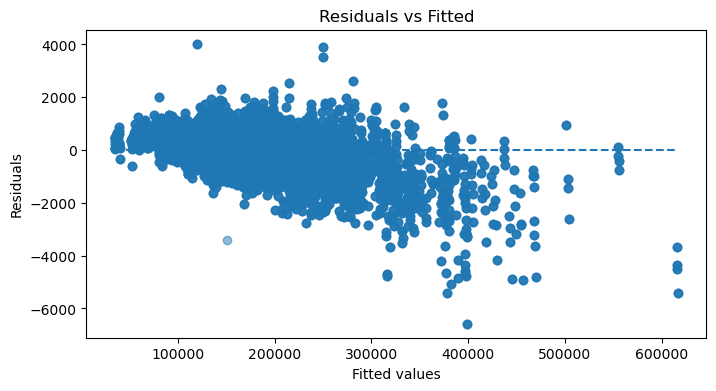

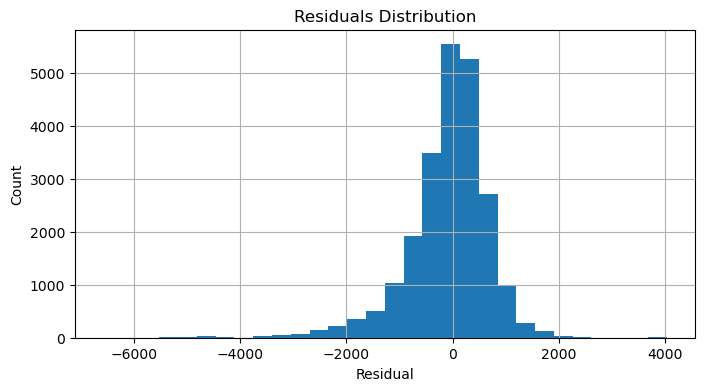

In [34]:
residuals = y_true - y_pred 

plt.figure(figsize=(8, 4))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), linestyles='dashed')

plt.title('Residuals vs Fitted')

plt.xlabel('Fitted values')
plt.ylabel('Residuals')

plt.show()

plt.figure(figsize=(8, 4))

pd.Series(residuals).hist(bins=30)

plt.title('Residuals Distribution')

plt.xlabel('Residual')
plt.ylabel('Count')

plt.show()


## 잔차 분석 해석

- Residuals vs Fitted 플롯을 통해 예측값에 따른 잔차 패턴 확인  
- 중앙선(0)을 기준으로 잔차가 고르게 분포하는지 검토  
- Residuals Distribution을 통해 잔차의 정규성 여부 및 이상치 여부 파악

### [1] Residuals vs Fitted Plot 해석

- 잔차가 전체적으로 0을 중심으로 고르게 분포함
    
    → 선형 회귀 모델의 선형성 가정 만족
    
- 예측값이 커질수록 잔차의 분산이 증가하는 경향 존재
    
    → 등분산성 가정 위배 가능성 존재
    
- 잔차가 특정한 곡선 형태를 따르지 않음
    
    → 비선형성 신호는 뚜렷하지 않음
    
- 고가 영역에서 음의 잔차가 몰려 있는 경향 존재
    
    → 고가 예측에서 과소추정 발생 가능성 내포
    

**요약**: 잔차는 전반적으로 무작위로 분포하나, 고가 예측 구간에서 잔차 분산 증가와 과소추정 경향이 나타나는 등, 등분산성 위반 가능성이 존재함

### [2] Residuals Distribution Plot 해석

- 잔차 분포가 중심(0)을 기준으로 대체로 종형 분포에 가까운 형태를 가짐
    
    → 정규성 가정 대체로 만족
    
- 다만 잔차 분포의 왼쪽 꼬리가 상대적으로 두꺼운 형태를 보임
    
    → 음의 잔차가 일부 과도하게 발생하는 경향 존재
    
    → 예측값이 실제값보다 과도하게 큰 경우 발생 가능성 시사
    

**요약**: 잔차 분포는 정규분포에 근접하나, 왼쪽으로의 비대칭성이 존재하며, 이는 일부 과도한 과대예측을 의미함


## 메타 모델 기여도 해석

메타 모델(LinearRegression)의 계수는 각 기본 모델 예측에 대한 가중치임.  
가중치 크기를 통해 각 모델의 기여도를 파악함.


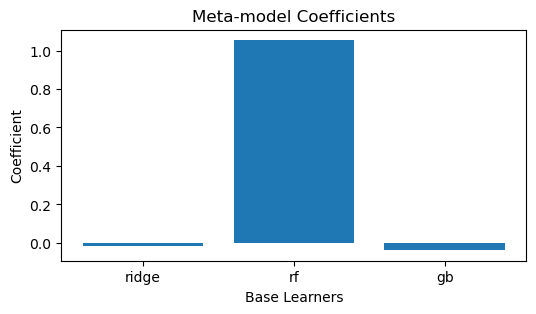

ridge coefficient: -0.0139
rf coefficient: 1.0537
gb coefficient: -0.0381


In [35]:
meta_coef = stack_model.final_estimator_.coef_  
est_names = [name for name, _ in estimators]    

plt.figure(figsize=(6, 3))

plt.bar(est_names, meta_coef)

plt.title('Meta-model Coefficients')

plt.xlabel('Base Learners')
plt.ylabel('Coefficient')

plt.show()

for name, coef in zip(est_names, meta_coef):
    print(f"{name} coefficient: {coef:.4f}")


## 메타 모델 기여도 해석

- 계수가 큰 모델이 앙상블 예측에 더 큰 기여도를 가짐  
- 음수 계수가 있다면 해당 모델이 메타 모델에서 부정적 영향력을 가짐

### 그래프 해석: Meta-model Coefficients]

- `rf` (랜덤 포레스트)의 계수가 **1.0 이상 수준으로 압도적으로 높음**
    
    → 메타 모델이 최종 예측 시 **거의 전적으로 랜덤 포레스트의 예측 결과에 의존함**
    
- `ridge` (릿지 회귀)와 `gb` (그래디언트 부스팅)의 계수는 **0에 가깝고 미미한 수준**
    
    → 두 모델은 메타 모델의 최종 예측에 **거의 기여하지 않음**
   

### [요약]

- 메타 모델이 `rf` 기반 예측을 **주 예측 신호로 사용함**
- `ridge`, `gb`는 예측력 또는 상보성이 낮아 **기여도가 미미함**
- 스태킹 구조에서의 **모델 선택 비중이 지나치게 한쪽으로 치우친 상태임**


### [추가 해석]

- 랜덤 포레스트의 성능이 탁월했거나,
    
    릿지와 GBM이 중복된 정보 또는 노이즈를 포함했을 가능성 존재
    
- 다양한 base 모델의 기여를 유도하기 위해서는 **모델 간 예측 다양성 확보가 중요함**


---

# 10. 비즈니스 적용 관점 인사이트 및 추가 실험 고려 사항


1. 인사이트  
   - **총 실내 면적(TotalSF)** 및 **주택 연령(HouseAge)** 변수가 가격 예측에 큰 영향력을 보임.  
   - 특정 **이웃(Neighborhood)** 그룹의 평균 가격 차이가 크게 나타나므로, 지역별 가격 전략 수립 필요.

2. 비즈니스 활용 방안  
   - **부동산 시세 예측 서비스**: 실거래 가격 예측 API로 활용하여 고객에게 매물 가치 제안.  
   - **투자 의사결정 지원**: 주요 피처별 민감도 분석 결과를 기반으로 투자 우선순위 설정.  
   - **리노베이션 ROI 분석**: 리모델링 연령(RemodAge) 변수 활용하여 리모델링 시점별 수익률 예측.

3. 추가 실험 고려 사항  
   - 외부 데이터 통합: **지역 경제 지표(예: 실업률, 인구 증가율)**, **학군 정보**, **교통 접근성** 데이터와 결합하여 성능 향상.  
   - 딥러닝 모델 적용: **Tabular Neural Network** 또는 **AutoGluon**, **H2O AutoML** 도구를 활용한 비교 실험.  
   - 시계열 분석: **월별·분기별 판매 추이**를 반영하기 위한 시계열 회귀(ARIMA, Prophet) 모델 실험.  
   - 고차 상호작용 파생 변수: **변수 간 곱셈·제곱·상호작용 항** 추가로 비선형 관계 포착.
